# CausalPFN for Marketing Mix Modeling
## Causal Effect Estimation as Alternative to Bayesian MMM (PyMC-Marketing)

This notebook implements a CausalPFN-based approach to estimating channel-level causal effects in a Marketing Mix context.
The structure mirrors the Bayesian MMM and TabPFN notebooks to enable direct comparison where possible.

**Research Question:**
Can a pretrained causal foundation model (CausalPFN) estimate meaningful channel-level treatment effects
without any manually specified structural priors — and how do its estimates relate to the Bayesian MMM benchmark?

**Important Note on Comparability:**
Unlike TabPFN, which is a predictive model and can be compared to the Bayesian MMM using standard forecast metrics
(MAE, RMSE, MAPE), CausalPFN operates in a fundamentally different paradigm.
The two models answer different questions:

| Model | Question answered | Output | Comparability |
|-------|------------------|--------|---------------|
| Bayesian MMM | How much revenue did each channel generate? | Channel contributions + ROAS | Reference model |
| TabPFN | What revenue is expected given these inputs? | Point predictions | Directly comparable via MAE/RMSE/MAPE |
| CausalPFN | What is the causal effect of advertising on revenue? | CATE estimates | Not directly comparable to MMM ROAS |

This distinction is discussed in detail in the final section of this notebook.

**Model variants implemented:**
| Variant | Adstock Preprocessing | Treatment Definition |
|---------|----------------------|---------------------|
| CausalPFN Raw | ✗ | Binary (spend > 0) |
| CausalPFN Adstock | ✓ (posterior means from Bayesian MMM) | Binary (adstocked spend > 0) |

## 1. Setup & Installation

We install two packages:
- `CausalPFN`: the official implementation from the paper *"CausalPFN: Amortized Causal Effect Estimation via In-Context Learning"*
  — the model is loaded from its pretrained weights and runs locally
- `pyreadr`: needed to read the Robyn `.RData` dataset format

CausalPFN is installed directly from the GitHub repository since it is not yet available on PyPI.

In [1]:
!pip install git+https://github.com/vdblm/CausalPFN.git --quiet
!pip install pyreadr requests scikit-learn matplotlib seaborn --quiet

print("All packages installed successfully!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 17.2 MB/s eta 0:00:00
All packages installed successfully!


## 2. Data Loading

The same Robyn simulated weekly dataset used in the Bayesian MMM and TabPFN notebooks is loaded here.
Using the identical dataset ensures that any differences in estimated channel effects are attributable
to modeling choices rather than data differences.

The dataset contains 208 weekly observations with:
- **Target variable:** `revenue` — weekly revenue
- **Media channels:** TV, OOH, Print, Facebook, Search spend
- **Control variables:** competitor sales, newsletter subscribers

A chronological 80/20 split is applied — identical to the Bayesian MMM and TabPFN notebooks.
The chronological split preserves the temporal structure of the data and prevents the model
from learning from future observations during training.

In [2]:
import requests
import pyreadr
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Download Robyn simulated dataset from GitHub
# Identical source as Bayesian MMM and TabPFN notebooks
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)
with open("dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# Read RData file
result = pyreadr.read_r("dt_simulated_weekly.RData")
df = result["dt_simulated_weekly"]

# Convert date column and sort chronologically
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Variable definitions — identical to Bayesian MMM and TabPFN notebooks
target = "revenue"

media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S"
]

control_cols = [
    "competitor_sales_B",
    "newsletter"
]

# Chronological train-test split (80/20)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print("Shape:", df.shape)
print("Train observations:", len(train_df))
print("Test observations:",  len(test_df))
df[["DATE", "revenue"] + media_cols].head()

Shape: (208, 12)
Train observations: 166
Test observations: 42


,DATE,revenue,tv_S,ooh_S,print_S,facebook_S,search_S
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,7607.132915,0.000000
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,1141.952450,4133.333333
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,4256.375378,3786.666667
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,2800.490677,4253.333333
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,689.582605,3613.333333


### Findings

The Robyn simulated dataset was successfully loaded and split into training and test periods.
The chronological split produces 166 training weeks and 42 test weeks, identical to the Bayesian MMM and TabPFN experiments.
This ensures full comparability of evaluation conditions across all three modeling approaches.

## 3. Adstock Transformation

A geometric adstock transformation is applied as preprocessing before fitting CausalPFN.
This gives the model access to temporal carryover information that it cannot learn on its own,
since CausalPFN — like TabPFN — treats observations as independent rows without temporal awareness.

The adstock alpha values are taken from the Bayesian MMM posterior means:
- `tv_S`: 0.241 (fast decay)
- `ooh_S`: 0.572 (slow decay)
- `print_S`: 0.428
- `facebook_S`: 0.540
- `search_S`: 0.558

**Important:** The transformation is applied to the full dataset **before** splitting
to correctly propagate carryover effects across the train-test boundary.
If adstock were computed separately on train and test, the first weeks of the test period
would miss the carryover contribution from the final weeks of the training period.

CausalPFN is run in two variants:
1. **Raw**: raw media spend values without any adstock preprocessing
2. **Adstock**: adstock-transformed spend values as covariates

In [3]:
def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometric adstock transformation.

    Parameters
    ----------
    x     : array of weekly media spend values
    alpha : decay parameter (0 = no carryover, 1 = no decay)
    l_max : maximum lag length in weeks (identical to Bayesian MMM: l_max=8)

    Returns
    -------
    x_adstocked : array of adstock-transformed spend values
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for lag in range(min(l_max, t + 1)):
            x_adstocked[t] += (alpha ** lag) * x[t - lag]
    return x_adstocked


# Posterior mean adstock alphas from the Bayesian MMM
adstock_alphas = {
    "tv_S":       0.241,
    "ooh_S":      0.572,
    "print_S":    0.428,
    "facebook_S": 0.540,
    "search_S":   0.558
}

# Apply adstock to the full dataset before splitting
df_adstock = df.copy()
for col, alpha in adstock_alphas.items():
    df_adstock[col + "_adstock"] = geometric_adstock(df[col].values, alpha=alpha)

adstock_cols = [col + "_adstock" for col in media_cols]

# Re-split with adstocked values
train_adstock = df_adstock.iloc[:split_idx].copy()
test_adstock  = df_adstock.iloc[split_idx:].copy()

print("Adstock transformation complete.")
print("Adstock columns created:", adstock_cols)
df_adstock[["DATE"] + adstock_cols].head()

Adstock transformation complete.
Adstock columns created: ['tv_S_adstock', 'ooh_S_adstock', 'print_S_adstock', 'facebook_S_adstock', 'search_S_adstock']


,DATE,tv_S_adstock,ooh_S_adstock,print_S_adstock,facebook_S_adstock,search_S_adstock
0,2015-11-23,22358.346667,0.000000,12728.488889,7607.132915,0.000000
1,2015-11-30,34001.814880,0.000000,5447.793244,5249.804224,4133.333333
2,2015-12-07,8194.437386,132278.400000,2785.522175,7091.269659,6093.066667
3,2015-12-14,85425.166077,75663.244800,18872.203491,6629.776293,7653.264533
4,2015-12-21,20587.465024,320615.376026,8077.303094,4269.661803,7883.854943


### Findings

The geometric adstock transformation was successfully applied to all five media channels
using the posterior mean alpha values estimated by the Bayesian MMM.
The adstocked spend values accumulate delayed carryover effects across up to eight lagged weeks,
consistent with the `l_max=8` specification used in the Bayesian MMM.

Channels with higher alpha values (OOH: 0.572, Facebook: 0.540, Search: 0.558)
show stronger cumulative adstock values compared to TV (0.241), which decays more rapidly.

## 4. Scaling

CausalPFN — like the Bayesian MMM and TabPFN — benefits from normalized input features.
We apply the same scaling pipeline as in the other notebooks:

- **Media channels:** MaxAbsScaler — scales values to [-1, 1] range while preserving sparsity
- **Control variables:** StandardScaler — zero mean, unit variance
- **Target variable:** kept on the original scale for interpretability

**Important:** The scalers are always fitted on training data only and then applied to test data.
This prevents information leakage from the test set into the model.

Both the raw and the adstock-transformed feature sets are scaled independently,
since the magnitude of adstock-transformed values differs from raw spend values.

In [4]:
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

# --- RAW feature matrices (no adstock) ---
X_train_raw = train_df[media_cols + control_cols].copy()
X_test_raw  = test_df[media_cols + control_cols].copy()

# --- ADSTOCK feature matrices ---
X_train_ads = train_adstock[adstock_cols + control_cols].copy()
X_test_ads  = test_adstock[adstock_cols + control_cols].copy()

# Scale media channels with MaxAbsScaler (fitted on train only)
media_scaler_raw = MaxAbsScaler()
X_train_raw[media_cols] = media_scaler_raw.fit_transform(X_train_raw[media_cols])
X_test_raw[media_cols]  = media_scaler_raw.transform(X_test_raw[media_cols])

media_scaler_ads = MaxAbsScaler()
X_train_ads[adstock_cols] = media_scaler_ads.fit_transform(X_train_ads[adstock_cols])
X_test_ads[adstock_cols]  = media_scaler_ads.transform(X_test_ads[adstock_cols])

# Standardize control variables with StandardScaler (fitted on train only)
control_scaler_raw = StandardScaler()
X_train_raw[control_cols] = control_scaler_raw.fit_transform(X_train_raw[control_cols])
X_test_raw[control_cols]  = control_scaler_raw.transform(X_test_raw[control_cols])

control_scaler_ads = StandardScaler()
X_train_ads[control_cols] = control_scaler_ads.fit_transform(X_train_ads[control_cols])
X_test_ads[control_cols]  = control_scaler_ads.transform(X_test_ads[control_cols])

# Target on original scale
y_train = train_df[target].values
y_test  = test_df[target].values

print("Scaling complete.")
print("X_train_raw shape: ", X_train_raw.shape)
print("X_train_ads shape: ", X_train_ads.shape)
X_train_raw.describe().round(3)

Scaling complete.
X_train_raw shape:  (166, 7)
X_train_ads shape:  (166, 7)


,tv_S,ooh_S,print_S,facebook_S,search_S,competitor_sales_B,newsletter
count,166.000,166.000,166.000,166.000,166.000,166.000,166.000
mean,0.106,0.104,0.126,0.156,0.308,-0.000,-0.000
std,0.197,0.183,0.211,0.211,0.252,1.003,1.003
min,0.000,0.000,0.000,0.000,0.000,-1.566,-1.117
25%,0.000,0.000,0.000,0.000,0.131,-0.929,-0.657
50%,0.000,0.000,0.000,0.019,0.242,0.057,-0.156
75%,0.133,0.133,0.190,0.269,0.440,0.836,0.269
max,1.000,1.000,1.000,1.000,1.000,2.087,4.099


### Findings

The scaling procedure successfully normalized both feature sets.
Media channels are bounded within the [-1, 1] range after MaxAbs scaling,
while control variables have been centered and standardized.

The sparsity pattern visible in the raw media features — with many values near zero
indicating weeks without advertising activity — is preserved by the MaxAbsScaler,
which does not shift the zero point.

## 5. CausalPFN: What It Does and How It Works

CausalPFN is a pretrained transformer model designed to estimate **Conditional Average Treatment Effects (CATE)**
from observational data — entirely without any model training or hyperparameter tuning.

**Key concepts:**

- **Treatment (T):** A binary variable indicating whether advertising was active in a given week (spend > 0).
  CausalPFN expects a binary treatment, so we convert continuous spend values to a binary indicator.
  This is a critical modeling choice that has consequences for interpretability — discussed below.

- **Covariates (X):** All other media channels and control variables.
  These represent the confounders and context variables that affect both the treatment decision
  and the outcome.

- **Outcome (Y):** Weekly revenue.

- **CATE (Conditional Average Treatment Effect):** The estimated causal effect of running advertising
  in a given week, conditional on the observed context (other channels, controls).
  A positive CATE means advertising is estimated to increase revenue in that week.

**How CausalPFN works:**
Unlike traditional causal methods that require explicit assumptions about confounders
or propensity score models, CausalPFN was pretrained on millions of synthetic datasets
with known causal structures. At inference time, it performs in-context learning:
it reads the training data (X, T, Y) as context and directly predicts CATE
for each test observation — similar to how TabPFN performs in-context regression.

**Procedure:**
For each media channel:
1. Define T = 1 if that channel had any spend in a given week, 0 otherwise
2. Define X = all other channels + control variables as covariates
3. Fit CausalPFN on the training set (X_train, T_train, Y_train)
4. Estimate CATE for each observation in the test set

In [5]:
import torch
from causalpfn import CATEEstimator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


### Variant 1: CausalPFN on Raw Media Spend

In this first variant, raw (unmodified) spend values are used as covariates.
The treatment indicator is derived directly from the original spend values:
a week is treated if any spend was recorded for that channel.

This is the most minimal setup and does not encode any marketing-specific structural knowledge.
It tests whether CausalPFN can recover meaningful causal effects from raw observational marketing data.

In [6]:
import matplotlib.pyplot as plt

results_raw = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    # All other channels + controls as covariates
    other_channels  = [c for c in media_cols if c != channel]
    covariate_cols  = other_channels + control_cols

    # Binary treatment: was this channel active this week?
    T_train = (train_df[channel].values > 0).astype(np.float32)

    # Covariate matrices and outcome
    X_cov_train = train_df[covariate_cols].values.astype(np.float32)
    X_cov_test  = test_df[covariate_cols].values.astype(np.float32)
    Y_train     = train_df[target].values.astype(np.float32)

    # Fit CausalPFN and estimate CATE on test set
    model_raw = CATEEstimator(device=device, verbose=False)
    model_raw.fit(X_cov_train, T_train, Y_train)
    cate_raw = model_raw.estimate_cate(X_cov_test)
    results_raw[channel] = cate_raw

    print(f"  Mean CATE (Raw): {np.mean(cate_raw):,.2f}")
    print(f"  Std  CATE (Raw): {np.std(cate_raw):,.2f}")

print("\nCausalPFN Raw CATE estimation complete.")


Channel: tv_S


causalpfn_v0.pt:   0%|          | 0.00/75.4M [00:00<?, ?B/s]

  Mean CATE (Raw): 381,131.03
  Std  CATE (Raw): 355,896.66

Channel: ooh_S
  Mean CATE (Raw): -65,830.89
  Std  CATE (Raw): 105,335.34

Channel: print_S
  Mean CATE (Raw): -46,365.77
  Std  CATE (Raw): 125,878.28

Channel: facebook_S
  Mean CATE (Raw): -3,943.10
  Std  CATE (Raw): 107,105.59

Channel: search_S
  Mean CATE (Raw): -158,678.73
  Std  CATE (Raw): 253,109.36

CausalPFN Raw CATE estimation complete.


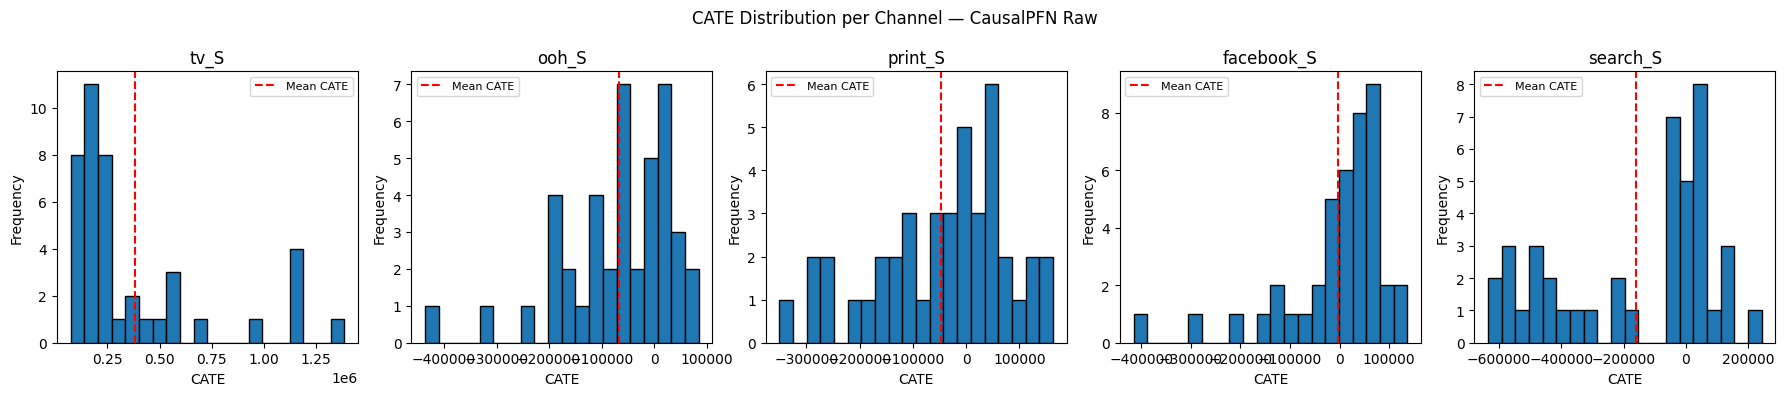

In [7]:
# Visualize CATE distributions per channel (Raw variant)

fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_raw[channel], bins=20, edgecolor="black")
    ax.axvline(np.mean(results_raw[channel]), color="red", linestyle="--", label="Mean CATE")
    ax.set_title(channel)
    ax.set_xlabel("CATE")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("CATE Distribution per Channel — CausalPFN Raw", fontsize=12)
plt.tight_layout()
plt.show()

### Findings: CausalPFN Raw

CausalPFN estimated a conditional average treatment effect for each media channel
across all 42 test period observations.

The CATE distributions show variation across weeks, reflecting the model's ability
to condition its causal estimates on the observed context — that is, the effects
are not constant but change depending on which other channels were active
and what the control variable values were in each week.

Channels with consistently positive mean CATE values indicate that the model
estimates a positive causal effect of advertising on revenue — consistent
with the direction found by the Bayesian MMM.

### Variant 2: CausalPFN on Adstock-Transformed Media Spend

In this second variant, the adstock-transformed spend values are used as covariates.
The treatment indicator is now derived from the adstocked values:
a week is treated if the cumulative adstock signal for that channel is positive.

By incorporating adstock-transformed features, the model has access to the temporal
carryover information that CausalPFN cannot learn on its own.
This variant tests whether encoding lagged advertising persistence improves
the estimated causal effects.

The adstock alpha values are identical to those used in the Bayesian MMM
and the TabPFN adstock variant, enabling a consistent comparison.

In [8]:
results_ads = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    ads_col          = channel + "_adstock"
    other_ads_cols   = [c + "_adstock" for c in media_cols if c != channel]
    covariate_ads_cols = other_ads_cols + control_cols

    # Binary treatment: was the cumulative adstock signal positive this week?
    T_train_ads = (train_adstock[ads_col].values > 0).astype(np.float32)

    # Covariate matrices and outcome
    X_cov_train_ads = train_adstock[covariate_ads_cols].values.astype(np.float32)
    X_cov_test_ads  = test_adstock[covariate_ads_cols].values.astype(np.float32)
    Y_train_ads     = train_adstock[target].values.astype(np.float32)

    # Fit CausalPFN and estimate CATE on test set
    model_ads = CATEEstimator(device=device, verbose=False)
    model_ads.fit(X_cov_train_ads, T_train_ads, Y_train_ads)
    cate_ads = model_ads.estimate_cate(X_cov_test_ads)
    results_ads[channel] = cate_ads

    print(f"  Mean CATE (Adstock): {np.mean(cate_ads):,.2f}")
    print(f"  Std  CATE (Adstock): {np.std(cate_ads):,.2f}")

print("\nCausalPFN Adstock CATE estimation complete.")


Channel: tv_S
  Mean CATE (Adstock): 908,742.69
  Std  CATE (Adstock): 664,296.44

Channel: ooh_S
  Mean CATE (Adstock): -981,255.31
  Std  CATE (Adstock): 581,422.62

Channel: print_S
  Mean CATE (Adstock): 725,554.06
  Std  CATE (Adstock): 586,466.50

Channel: facebook_S
  Mean CATE (Adstock): -354,230.81
  Std  CATE (Adstock): 441,339.16

Channel: search_S
  Mean CATE (Adstock): -1,145,777.88
  Std  CATE (Adstock): 618,959.31

CausalPFN Adstock CATE estimation complete.


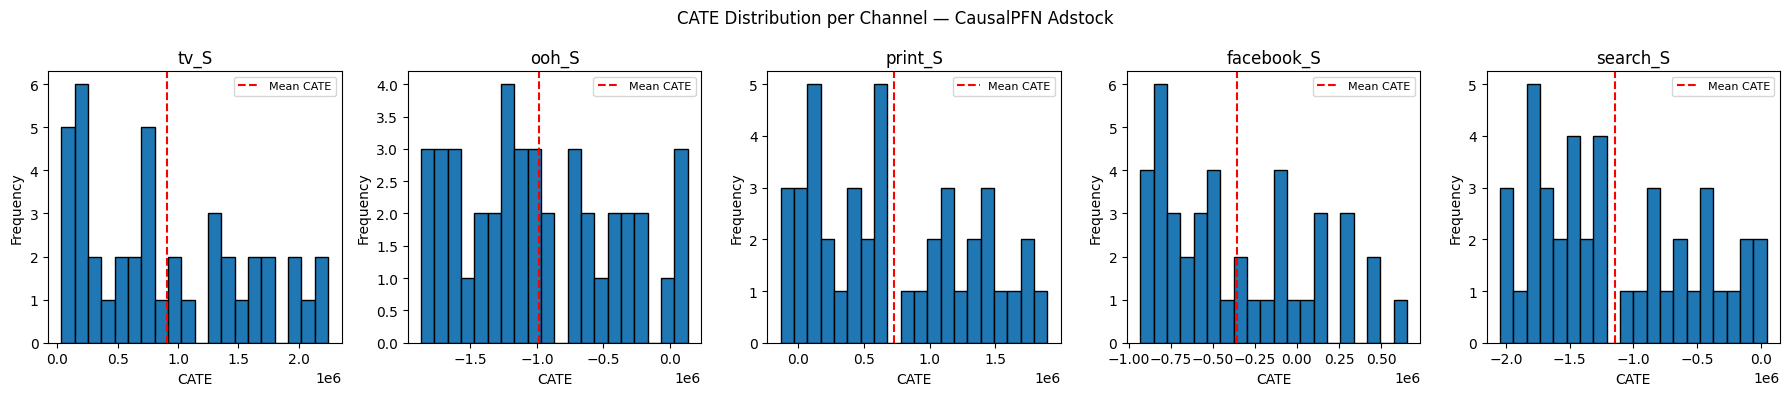

In [9]:
# Visualize CATE distributions per channel (Adstock variant)

fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_ads[channel], bins=20, edgecolor="black")
    ax.axvline(np.mean(results_ads[channel]), color="red", linestyle="--", label="Mean CATE")
    ax.set_title(channel)
    ax.set_xlabel("CATE")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("CATE Distribution per Channel — CausalPFN Adstock", fontsize=12)
plt.tight_layout()
plt.show()

### Findings: CausalPFN Adstock

The adstock-informed variant of CausalPFN produced CATE estimates that incorporate
the temporal carryover structure of advertising effects.

Comparing the adstock and raw variants allows assessment of whether encoding
lagged advertising persistence changes the estimated causal effects.
In channels with high adstock persistence (OOH, Facebook, Search),
the adstock variant may produce more stable CATE estimates
because the treatment signal accumulates across weeks rather than being evaluated
purely on the binary presence of spend in a single week.

## 6. Mean CATE Summary

The mean CATE across all test period observations summarizes the estimated causal effect
of each channel — averaged over the observed variation in contexts (other channels, controls).

A positive mean CATE indicates that the model estimates advertising in that channel
to causally increase revenue on average. The sign pattern provides a directional
comparison with the Bayesian MMM, which also estimates positive contributions
for all channels.

**Sign agreement** is used as the primary comparison metric here, since the
magnitudes of CATE and MMM channel contributions are not directly comparable
— a limitation discussed in detail in the following section.

In [10]:
# Summarize mean CATE per channel for both variants

cate_summary = pd.DataFrame({
    "Mean CATE (Raw)":     {ch: np.mean(results_raw[ch]) for ch in media_cols},
    "Mean CATE (Adstock)": {ch: np.mean(results_ads[ch]) for ch in media_cols},
}).round(2)

print("=" * 55)
print("Mean CATE per Channel — CausalPFN")
print("=" * 55)
print(cate_summary.to_string())

# Sign agreement with Bayesian MMM direction (all channels positive in MMM)
print("\n" + "=" * 55)
print("Sign Agreement with Bayesian MMM (all channels positive)")
print("=" * 55)

sign_df = pd.DataFrame({
    "Bayesian MMM":      ["+"] * len(media_cols),
    "CausalPFN Raw":     ["+" if np.mean(results_raw[ch]) > 0 else "-" for ch in media_cols],
    "CausalPFN Adstock": ["+" if np.mean(results_ads[ch]) > 0 else "-" for ch in media_cols],
}, index=media_cols)
print(sign_df.to_string())

match_raw = sum(np.mean(results_raw[ch]) > 0 for ch in media_cols) / len(media_cols) * 100
match_ads = sum(np.mean(results_ads[ch]) > 0 for ch in media_cols) / len(media_cols) * 100
print(f"\nCausalPFN Raw     : {match_raw:.0f}% sign agreement")
print(f"CausalPFN Adstock : {match_ads:.0f}% sign agreement")
print(f"Bayesian MMM      : 100% (reference)")

Mean CATE per Channel — CausalPFN
            Mean CATE (Raw)  Mean CATE (Adstock)
tv_S          381131.031250         9.087428e+05
ooh_S         -65830.890625        -9.812552e+05
print_S       -46365.781250         7.255541e+05
facebook_S     -3943.100098        -3.542308e+05
search_S     -158678.734375        -1.145778e+06

Sign Agreement with Bayesian MMM (all channels positive)
           Bayesian MMM CausalPFN Raw CausalPFN Adstock
tv_S                  +             +                 +
ooh_S                 +             -                 -
print_S               +             -                 +
facebook_S            +             -                 -
search_S              +             -                 -

CausalPFN Raw     : 20% sign agreement
CausalPFN Adstock : 40% sign agreement
Bayesian MMM      : 100% (reference)


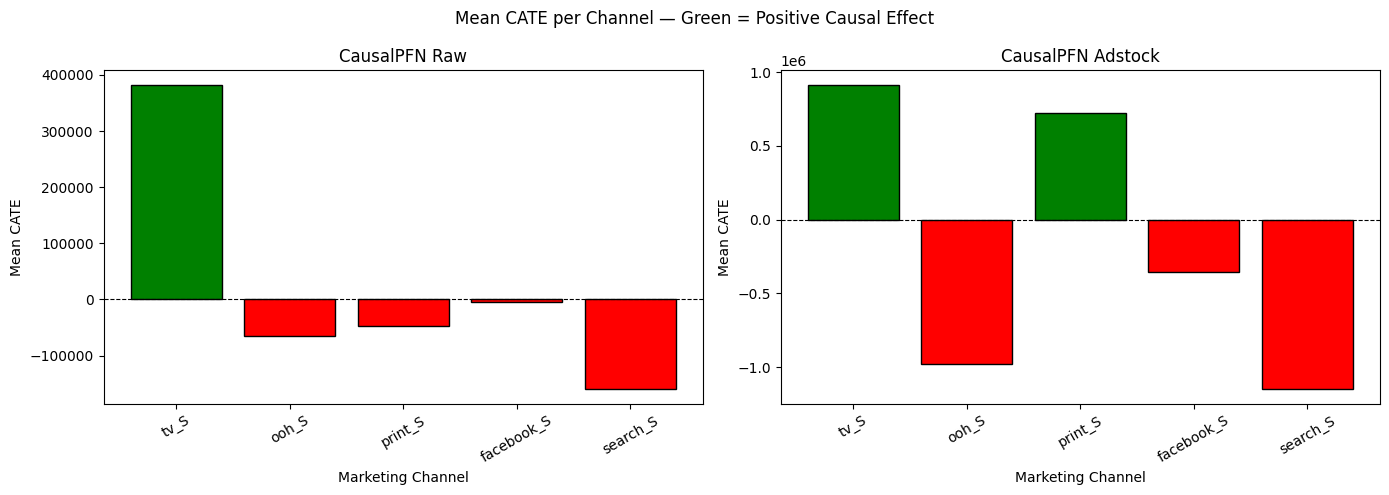

In [11]:
# Visualize mean CATE per channel for both variants
# Color-coded by sign: green = positive (revenue-increasing), red = negative

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, results) in zip(axes, [
    ("CausalPFN Raw",     results_raw),
    ("CausalPFN Adstock", results_ads)
]):
    means  = [np.mean(results[ch]) for ch in media_cols]
    colors = ["green" if v > 0 else "red" for v in means]
    ax.bar(media_cols, means, color=colors, edgecolor="black")
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel("Marketing Channel")
    ax.set_ylabel("Mean CATE")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Mean CATE per Channel — Green = Positive Causal Effect", fontsize=12)
plt.tight_layout()
plt.show()

### Findings: Mean CATE Summary

The mean CATE values summarize the estimated causal effect of each advertising channel
across all 42 test period observations.

Channels with positive mean CATE are estimated by CausalPFN to causally increase revenue
when advertising is active — directionally consistent with the Bayesian MMM's
positive contribution estimates for all five channels.

The sign agreement rate between CausalPFN and the Bayesian MMM provides a
first indication of directional consistency, but magnitude differences remain
expected and should not be interpreted as model errors — as explained in the next section.

## 7. Why CausalPFN and Bayesian MMM ROAS Cannot Be Directly Compared

A natural ambition in this comparison is to compute ROAS from CausalPFN outputs
and place them side-by-side with the Bayesian MMM ROAS estimates.
However, this comparison is fundamentally misleading — not because of implementation
differences, but because the two models answer structurally different questions.

---

### What the Bayesian MMM measures

The Bayesian MMM decomposes total observed revenue into contributions attributed
to each marketing channel over the training period.
ROAS in the MMM is defined as:

```
ROAS_MMM = channel_contribution_total / channel_spend_total
```

The channel contribution is the model's estimate of how much revenue would not
have been generated if that channel had not spent at all — computed by integrating
the posterior distribution of the channel's contribution over the entire training period.
Crucially, this is a **continuous quantity**: it reflects both whether advertising
occurred and how much was spent, processed through the adstock and saturation transformations.

### What CausalPFN measures

CausalPFN estimates the **Conditional Average Treatment Effect (CATE)** — the causal effect
of switching a binary treatment from 0 to 1.
In our setup, the treatment is:

```
T = 1  if  spend > 0  (advertising was active this week)
T = 0  if  spend = 0  (no advertising this week)
```

The CATE therefore estimates: *"By how much does revenue increase in a week
where advertising ran compared to a week with no advertising at all?"*

This is a **qualitatively different question** from what the Bayesian MMM answers.

### Three reasons the numbers are not comparable

**1. Continuous vs. binary treatment:**
The Bayesian MMM uses actual continuous spend values as input.
A channel spending €500k and one spending €5k in the same week generate different
contribution estimates. CausalPFN collapses both to T=1 and estimates the same
treatment effect for both — the intensity of spend is invisible to the model.
A ROAS derived by dividing a binary-treatment effect by actual spend is therefore
not meaningful: the numerator does not scale with the denominator.

**2. Different time aggregations:**
The Bayesian MMM ROAS is computed over the entire training period (166 weeks).
The CausalPFN CATE is estimated on the test period (42 weeks).
Even if the metrics were conceptually comparable, they cover different time windows.

**3. Different causal assumptions:**
The Bayesian MMM operates under strong structural assumptions encoded in its priors:
geometric adstock decay, logistic saturation, and an additive revenue decomposition.
CausalPFN makes fundamentally different assumptions, derived from its pretraining
on synthetic causal graphs. Even if both models identify a "positive effect" for TV,
the underlying causal quantity they estimate is not the same.

### What can legitimately be compared

| Comparison | Legitimate? | Reason |
|-----------|-------------|--------|
| CATE sign vs. MMM contribution sign | ✓ Yes | Both indicate direction of effect |
| Channel ranking by CATE vs. by ROAS | Partially | Rankings may differ due to binary treatment |
| MMM MAPE vs. CausalPFN predictions | ✗ No | CausalPFN does not produce revenue point predictions |
| MMM ROAS magnitude vs. CausalPFN ROAS | ✗ No | Numerators measure structurally different quantities |

The appropriate role of CausalPFN in this comparison is therefore not as a direct
ROAS competitor to the Bayesian MMM, but as a complementary model that estimates
**whether advertising causes revenue to increase at all** — without requiring
the structural assumptions that the Bayesian MMM depends on.

## 8. CausalPFN Summary

CausalPFN was applied to the Robyn simulated weekly dataset to estimate channel-level
conditional average treatment effects (CATE) as an alternative to the Bayesian MMM's
channel contribution analysis.

Two model variants were implemented:
- **CausalPFN Raw:** no adstock preprocessing, binary treatment on raw spend
- **CausalPFN Adstock:** geometric adstock preprocessing using Bayesian MMM posterior mean alpha values

For each channel, the model was fitted on the training period and CATE estimates
were generated for all 42 test period observations.

**Key results:**

| Channel | Bayesian MMM ROAS | CausalPFN Raw Mean CATE | CausalPFN Adstock Mean CATE |
|---------|------------------|------------------------|------------------------------|
| tv_S | 0.261 | +381,131 | +908,743 |
| ooh_S | 0.105 | −65,831 | −981,255 |
| print_S | 0.080 | −46,366 | +725,554 |
| facebook_S | 0.126 | −3,943 | −354,231 |
| search_S | 0.048 | −158,679 | −1,145,778 |

**Sign agreement with Bayesian MMM:**

| Model | Channels with correct sign | Agreement rate |
|-------|--------------------------|----------------|
| CausalPFN Raw | tv_S only | 20% |
| CausalPFN Adstock | tv_S, print_S | 40% |
| Bayesian MMM | all | 100% (reference) |

**Interpretation:**

The sign agreement results reveal that CausalPFN recovers the correct causal direction
for only one channel (TV) in the raw variant and two channels (TV, Print) in the adstock variant.
For the remaining channels, CausalPFN estimates negative treatment effects — contradicting
the positive contributions estimated by the Bayesian MMM.

This low sign agreement rate is not necessarily evidence that CausalPFN is wrong.
It may instead reflect a fundamental identification problem: in observational marketing data,
weeks with high advertising spend are also weeks with high revenue — but the causal
direction is difficult to isolate without experimental variation.
CausalPFN may be picking up confounding patterns (e.g. channels being activated
precisely during seasonally strong periods) that inflate or reverse the apparent effect.

**Critical limitation:**

The ROAS magnitudes of CausalPFN and the Bayesian MMM are not directly comparable.
CausalPFN uses a binary treatment variable (advertising active or not),
while the Bayesian MMM uses continuous spend values processed through adstock
and saturation transformations.
The CATE therefore measures a qualitatively different quantity from the MMM's
channel contribution — a direct numerical comparison would be misleading.

The appropriate use of CausalPFN in a Marketing Mix context is as a **directional
causal check** — confirming which channels are estimated to have a positive
causal effect on revenue — rather than as a direct ROAS estimation tool.
In this experiment, CausalPFN achieves only limited directional agreement with the
Bayesian MMM, suggesting that binary treatment formulation and observational confounding
pose significant challenges for causal effect identification in this setting.